Generating the comparison between Linear Regression, Neural Network compared to true data

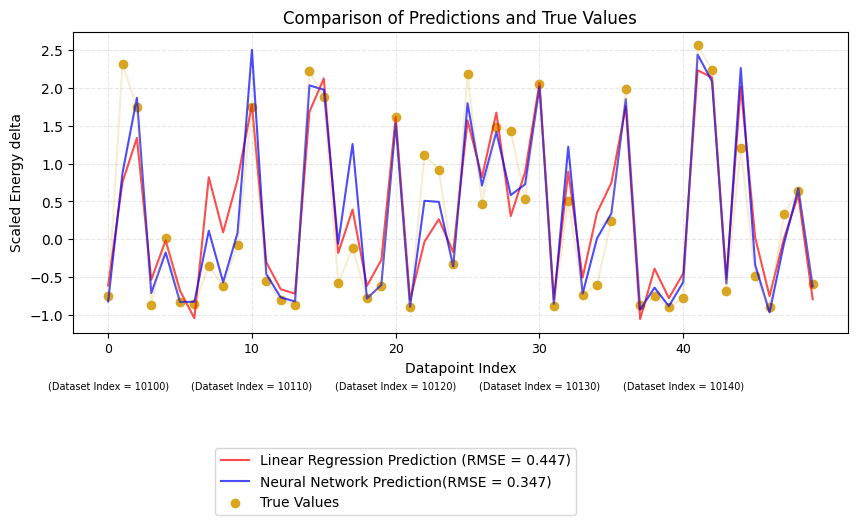

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pathlib import Path
#Since the test dataset has ~20000 rows, we will use between 10100-10140 rows for plot


linear = pd.read_csv("linear_test_dataset.csv",usecols=["Linear_Regression_Prediction"])
linear_range = linear.iloc[10100:10150].values
neural_network = pd.read_csv("neural_network_output.csv",usecols=["PyTorch_Predicted"])
neural_network_range = neural_network.iloc[10100:10150].values
true = pd.read_csv("linear_test_dataset.csv",usecols=["Energy delta[Wh]"])
true_range = true.iloc[10100:10150].values
x_values = np.arange(len(true_range))
original_indices = 10100 + x_values

plt.figure(figsize=(10, 7))
plt.plot(x_values, linear_range, label="Linear Regression Prediction (RMSE = 0.447)", color="red", alpha=0.7)
plt.plot(x_values, neural_network_range, label="Neural Network Prediction(RMSE = 0.347)", color="blue", alpha=0.7)
plt.plot(x_values, true_range, label="_nolegend_", color="goldenrod", alpha=0.2)
plt.scatter(x_values, true_range.ravel(), label="True Values", color="goldenrod")

xtick_positions = np.arange(0, len(true_range), 10)
plt.xticks(xtick_positions, [str(pos) for pos in xtick_positions], fontsize=9)
for pos in xtick_positions:
    plt.text(pos, -0.16, f"(Dataset Index = {10100 + pos})", transform=plt.gca().get_xaxis_transform(), ha="center", va="top", fontsize=7)
plt.subplots_adjust(bottom=0.45)

plt.xlabel("Datapoint Index")
plt.ylabel("Scaled Energy delta")
plt.title("Comparison of Predictions and True Values")
plt.legend(loc="upper center", bbox_to_anchor=(20, -0.36), bbox_transform=plt.gca().get_xaxis_transform(), ncol=1)
plt.grid(True, linestyle="--", alpha=0.3)
plt.savefig("comparison.png", dpi=300, bbox_inches="tight")
plt.draw()